# Differential Splicing Analysis with pylimma (pasilla dataset)

This tutorial walks through a differential splicing workflow -
testing which **exons** are differentially used between conditions
while accounting for overall gene-level expression. The underlying
test is a per-exon interaction evaluated via `diff_splice`.


**R-parity validation**: the sibling notebook [`pasilla_R_vs_Python.ipynb`](pasilla_R_vs_Python.ipynb) runs R limma 3.66.0 on the same input and compares the outputs numerically.

## Dataset

**Brooks et al. 2011, *Genome Research* 21:193-202**: *Drosophila melanogaster* S2 cells with RNAi knockdown of the splicing regulator *pasilla* (Ps) vs untreated controls. The shipped subset is the exon-level count matrix from the `pasilla` Bioconductor package.

## Pipeline

Differential splicing differs from the standard DE workflow:

- **Input**: exon-level counts (not gene-level).
- **Output**: `diff_splice` + `top_splice` replace `eBayes` +
  `top_table`.

Steps:

1. Load exon counts + metadata
2. Library-size QC
3. log-count density (KDE, per sample)
4. log2 transform
5. Design matrix
6. Fit per-exon linear models
7. `diff_splice` + `top_splice`
8. Top-ranked gene's exon-level logFC
9. Summary


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'data'))

import generate_data as gd

import pylimma

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 10)

# Shared plotting helpers used by every tutorial.

def _log_cpm(mat, lib_size):
    cpm = mat.div(lib_size, axis=1) * 1e6 if hasattr(mat, 'div') \
          else (mat / lib_size) * 1e6
    return np.log2(cpm + 1e-2)


def plot_log_cpm_density(mat, ax, title=""):
    '''Kernel-smoothed log-CPM density, one line per sample.

    Matches edgeR/limma's standard density plot (limma User's Guide
    Figure 15.1): a Gaussian KDE per sample drawn on a shared grid.
    '''
    from scipy.stats import gaussian_kde
    arr = mat.values if hasattr(mat, 'values') else np.asarray(mat)
    # Shared evaluation grid spanning the combined range.
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    grid = np.linspace(lo, hi, 200)
    for j in range(arr.shape[1]):
        col = arr[:, j]
        col = col[np.isfinite(col)]
        if col.size < 2:
            continue
        kde = gaussian_kde(col)
        ax.plot(grid, kde(grid), linewidth=0.8, alpha=0.7)
    ax.set_xlabel('log2 CPM')
    ax.set_ylabel('Density')
    ax.set_title(title)


def mds_coords(mat, top=500):
    '''Pairwise leading-logFC MDS, matching R limma's plotMDS.default.

    Returns the (n_samples, ndim) coordinate matrix and the percent of
    variance explained per dimension. We reuse pylimma's private
    _mds_coordinates for consistency with plot_mds().
    '''
    from pylimma.plotting import _mds_coordinates
    r = _mds_coordinates(np.asarray(mat, dtype=np.float64), top=top,
                         gene_selection='pairwise', ndim=2)
    lam = np.maximum(r['eigen_values'], 0.0)
    coords = r['eigen_vectors'] * np.sqrt(lam)
    return coords, r['var_explained']


def plot_mds_coloured(mat, groups, ax, top=500, title='MDS'):
    '''MDS scatter plot coloured by sample group.'''
    coords, var_exp = mds_coords(mat, top=top)
    pct = np.round(var_exp * 100).astype(int)
    groups = np.asarray(groups)
    levels = sorted(pd.unique(groups))
    palette = plt.get_cmap('tab10').colors
    for k, level in enumerate(levels):
        m = groups == level
        ax.scatter(coords[m, 0], coords[m, 1],
                   s=55, color=palette[k % len(palette)],
                   label=str(level), edgecolor='k', linewidth=0.3)
    ax.axhline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.4, linestyle=':')
    ax.set_xlabel(f'Leading logFC dim 1 ({pct[0]}%)')
    ax.set_ylabel(f'Leading logFC dim 2 ({pct[1]}%)')
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)


def plot_heatmap(E, groups, fit, n_top=50, ax=None):
    '''Heatmap of top-n DE rows showing BOTH directions.

    Picks the top n/2 genes with the most positive t and the top n/2
    with the most negative t (by smallest p within each side), then
    stacks them - up-regulated in the contrast at top, down-regulated
    at bottom. Row z-scored.'''
    t = np.asarray(fit['t']).ravel()
    p = np.asarray(fit['p_value']).ravel()
    half = n_top // 2
    up_pool   = np.where(t > 0)[0]
    down_pool = np.where(t < 0)[0]
    top_up    = up_pool[np.argsort(p[up_pool])[:half]]
    top_down  = down_pool[np.argsort(p[down_pool])[:n_top - half]]
    # Sort each block by signed t descending so most-up is top and
    # most-down is bottom.
    top_up   = top_up[np.argsort(-t[top_up])]
    top_down = top_down[np.argsort(-t[top_down])]
    ordered  = np.concatenate([top_up, top_down])

    mat = E[ordered]
    col_order = np.argsort(groups)
    mat_sorted = mat[:, col_order]
    z = (mat_sorted - mat_sorted.mean(axis=1, keepdims=True)) / \
        (mat_sorted.std(axis=1, keepdims=True) + 1e-8)

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_xticks(range(len(col_order)))
    ax.set_xticklabels(np.asarray(groups)[col_order], rotation=90, fontsize=6)
    ax.set_yticks([])
    ax.set_title(f'Top {n_top} DE genes (top {half} up + top {n_top - half} down; row z-scored)')
    return ax, im, ordered


## 1. Load exon counts and sample metadata

In [2]:
data = gd.load_pasilla()
counts  = data['counts']
targets = data['targets']
print(f"exon counts: {counts.shape}  (exons x samples)")
print(targets[['condition', 'type']])

exon counts: (14599, 7)  (exons x samples)
            condition         type
untreated1  untreated  single-read
untreated2  untreated  single-read
untreated3  untreated   paired-end
untreated4  untreated   paired-end
treated1      treated  single-read
treated2      treated   paired-end
treated3      treated   paired-end


## 2. Library sizes

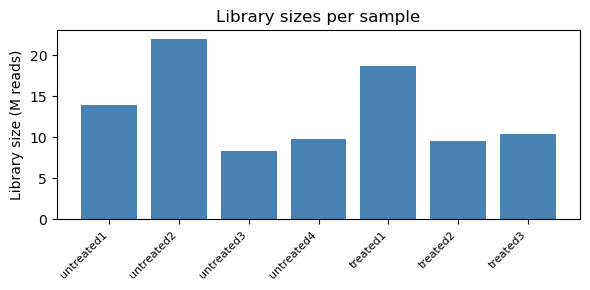

In [3]:
lib = counts.sum(axis=0)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(len(lib)), lib.values / 1e6, color='steelblue')
ax.set_xticks(range(len(lib)))
ax.set_xticklabels(counts.columns, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Library size (M reads)')
ax.set_title('Library sizes per sample')
fig.tight_layout()
plt.show()

## 3. log-count density (KDE)

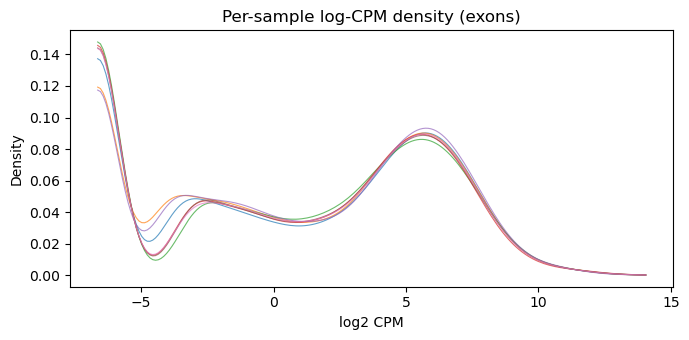

In [4]:
lc = _log_cpm(counts, lib)
fig, ax = plt.subplots(figsize=(7, 3.5))
plot_log_cpm_density(lc, ax, 'Per-sample log-CPM density (exons)')
fig.tight_layout()
plt.show()

## 4. log2 transform

For differential splicing, limma treats log-transformed exon counts
as a microarray-style matrix. voom is not used here; the
mean-variance trend is captured implicitly by the per-exon linear
model.

In [5]:
log2_counts = np.log2(counts.values.astype(float) + 1)
print(f"log2_counts range: [{log2_counts.min():.2f}, {log2_counts.max():.2f}]")

log2_counts range: [0.00, 18.46]


## 5. Design matrix

In [6]:
design, C = gd.build_two_group_design(targets['condition'])
design_df = pd.DataFrame(design, index=counts.columns,
                         columns=sorted(targets['condition'].unique()))
print(design_df)
print(f"\nContrast vector: {C.ravel()}  (treated - control)")

            treated  untreated
untreated1      0.0        1.0
untreated2      0.0        1.0
untreated3      0.0        1.0
untreated4      0.0        1.0
treated1        1.0        0.0
treated2        1.0        0.0
treated3        1.0        0.0

Contrast vector: [-1.  1.]  (treated - control)


## 6. Fit per-exon linear models

In [7]:
fit = pylimma.lm_fit(log2_counts, design)
print(f"coefficients shape: {fit['coefficients'].shape}")

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


coefficients shape: (14599, 2)


## 7. `e_bayes` + `diff_splice` + `top_splice`

The shipped exon matrix has no explicit gene annotation, so we
simulate a simple geneid grouping: five consecutive exons per
"gene". Real analyses would use a GTF-derived grouping.

In [8]:
fit = pylimma.e_bayes(fit)
geneid = (np.arange(counts.shape[0]) // 5).astype(str)

ds = pylimma.diff_splice(fit, geneid=geneid)
ts = pylimma.top_splice(ds, number=np.inf, sort_by='p')
print(f"top_splice output: {ts.shape}, columns: {list(ts.columns)}")
ts.head(10)

top_splice output: (2920, 5), columns: ['GeneID', 'NExons', 'F', 'P.Value', 'FDR']


/Users/John/Documents/Projects/staged/pylimma/pylimma/pylimma/squeeze_var.py:396: UserWarning: Zero sample variances detected, have been offset away from zero
  warnings.warn("Zero sample variances detected, have been offset away from zero")
/var/folders/0x/4309q_jn5xbf3zzq_4hcp2100000gn/T/ipykernel_99389/895928089.py:4: UserWarning: diff_splice: 14599 exons, 2920 genes, 0 with 1 exon, mean 5 exons/gene, max 5
  ds = pylimma.diff_splice(fit, geneid=geneid)


,GeneID,NExons,F,P.Value,FDR
0,85,5,2583.673589,1.883358e-34,5.499406e-31
1,1195,5,2013.896455,5.383258e-33,7.859557e-30
2,2847,5,1940.547358,8.867099e-33,8.630643e-30
3,2338,5,1809.610233,2.268798e-32,1.656223e-29
4,2158,5,1370.151358,9.536298e-31,5.569198e-28
5,301,5,1339.796840,1.288355e-30,6.269993e-28
6,2462,5,1265.720229,2.764835e-30,1.153331e-27
7,883,5,992.929347,7.173435e-29,2.618304e-26
8,2794,5,954.707733,1.213902e-28,3.938439e-26
9,178,5,944.913253,1.393761e-28,3.976064e-26


## 8. Top-ranked gene's exon-level fold changes

A gene with differential splicing shows some exons strongly
up-regulated while others are flat or down - a relative shift
rather than a uniform one.

Top gene: 85  (exons in gene: 5)


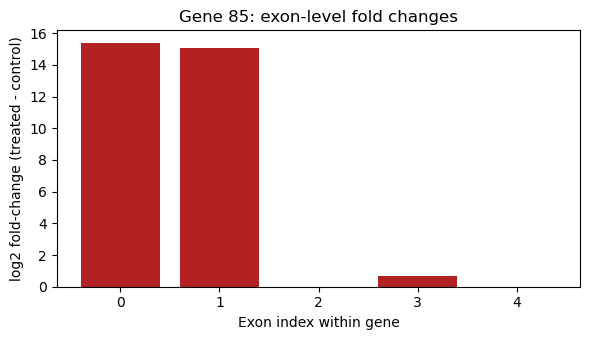

In [9]:
top_gene = str(ts.iloc[0]['GeneID'])
gene_mask = (geneid == top_gene)
exon_fc = fit['coefficients'][gene_mask, 0]
print(f"Top gene: {top_gene}  (exons in gene: {gene_mask.sum()})")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(len(exon_fc)), exon_fc,
       color=np.where(exon_fc > 0, 'firebrick', 'steelblue'))
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Exon index within gene')
ax.set_ylabel('log2 fold-change (treated - control)')
ax.set_title(f'Gene {top_gene}: exon-level fold changes')
fig.tight_layout()
plt.show()